In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelBinarizer
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout


In [5]:
import pandas as pd

data = pd.read_csv('Fruit.csv')

data.head(), data.info()



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 59 entries, 0 to 58
Data columns (total 7 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   fruit_label    59 non-null     int64  
 1   fruit_name     59 non-null     object 
 2   fruit_subtype  59 non-null     object 
 3   mass           59 non-null     int64  
 4   width          59 non-null     float64
 5   height         59 non-null     float64
 6   color_score    59 non-null     float64
dtypes: float64(3), int64(2), object(2)
memory usage: 3.4+ KB


(   fruit_label fruit_name fruit_subtype  mass  width  height  color_score
 0            1      apple  granny_smith   192    8.4     7.3         0.55
 1            1      apple  granny_smith   180    8.0     6.8         0.59
 2            1      apple  granny_smith   176    7.4     7.2         0.60
 3            2   mandarin      mandarin    86    6.2     4.7         0.80
 4            2   mandarin      mandarin    84    6.0     4.6         0.79,
 None)

In [6]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

X = data[['mass', 'width', 'height', 'color_score']]
y = data['fruit_label']


scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


encoder = LabelEncoder()
y_encoded = encoder.fit_transform(y)
y_onehot = to_categorical(y_encoded)


X_train, X_test, y_train, y_test = train_test_split(X_scaled, y_onehot, test_size=0.2, random_state=42)


model = Sequential([
    Dense(64, activation='relu', input_shape=(X_train.shape[1],)),
    Dropout(0.3),
    Dense(32, activation='relu'),
    Dropout(0.3),
    Dense(y_onehot.shape[1], activation='softmax')
])


model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])


history = model.fit(X_train, y_train, epochs=50, batch_size=8, validation_split=0.2, verbose=1)

test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=0)

test_loss, test_accuracy


Epoch 1/50


/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 61ms/step - accuracy: 0.2242 - loss: 1.5002 - val_accuracy: 0.1000 - val_loss: 1.3799
Epoch 2/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.2647 - loss: 1.4248 - val_accuracy: 0.2000 - val_loss: 1.3456
Epoch 3/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.2571 - loss: 1.4378 - val_accuracy: 0.5000 - val_loss: 1.3114
Epoch 4/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.4070 - loss: 1.3438 - val_accuracy: 0.6000 - val_loss: 1.2801
Epoch 5/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.4431 - loss: 1.2376 - val_accuracy: 0.7000 - val_loss: 1.2506
Epoch 6/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.6499 - loss: 1.2701 - val_accuracy: 0.7000 - val_loss: 1.2236
Epoch 7/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.6641 - loss: 1.1533 - val_accuracy: 0.8000 - val_loss: 1.1931
Epoch 8/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.5843 - loss: 1.1875 - val_accuracy: 0.9000 - val_loss: 1.1637
Epoch 9/50
5

(0.19540591537952423, 1.0)

In [7]:
test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=0)
print(f"Test Accuracy: {test_accuracy:.2f}")
print(f"Test Loss: {test_loss:.2f}")


Test Accuracy: 1.00
Test Loss: 0.20


In [8]:
predictions = model.predict(X_test)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step


In [9]:
import numpy as np
y_pred = np.argmax(predictions, axis=1)
y_true = np.argmax(y_test, axis=1)


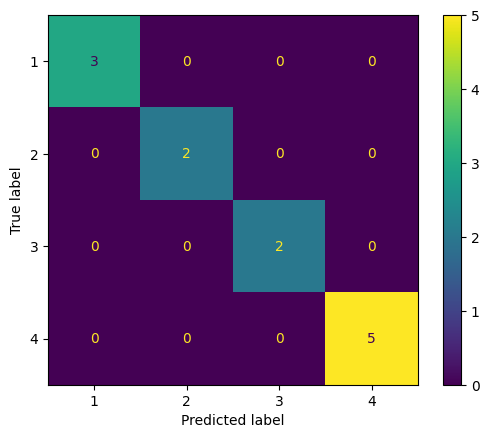

In [10]:
from sklearn.metrics import ConfusionMatrixDisplay
ConfusionMatrixDisplay.from_predictions(y_true, y_pred, display_labels=encoder.classes_)
